In [21]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib
importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

# Load Data

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = "/home/emily_zuetell/projects/poreallas/data/20260903_effects.zarr"
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

#Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_TAS_FORECAST_RAW_URI"]

In [3]:
#Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated = False)
baseline_period = analysis_utils.get_baseline_period(effect, years = 30)
#Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

#Socioeconomics
socioeconomics =  xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop', 'gdppc', 'iso3']]

# Compute Impact

In [66]:
socioeconomics.to_dataframe().to_csv("age_cohort_region_pop.csv")

In [68]:
region_pop = socioeconomics.to_dataframe()

In [69]:
region_pop[region_pop['iso3']=="IND"]

,pop0to4,pop5to64,pop65plus,pop,gdppc,iso3,year
region,,,,,,,
IND.1.1.1,2.222256e+04,2.492104e+05,2.170008e+04,2.931339e+05,7494.820578,IND,2026
IND.1.2.2,1.215376e+03,1.362959e+04,1.186801e+03,1.603182e+04,5549.593208,IND,2026
IND.10.121.371,1.543772e+06,1.731232e+07,1.507476e+06,2.036363e+07,12328.574782,IND,2026
IND.11.122.372,7.280667e+03,8.164756e+04,7.109489e+03,9.603801e+04,14504.412167,IND,2026
IND.11.122.373,1.565978e+04,1.756134e+05,1.529159e+04,2.065654e+05,14770.523347,IND,2026
...,...,...,...,...,...,...,...
IND.7.117.366,5.818247e+04,6.524755e+05,5.681453e+04,7.674749e+05,2621.009940,IND,2026
IND.8.118.367,3.912974e+04,4.388125e+05,3.820975e+04,5.161536e+05,4907.944582,IND,2026
IND.9.119.368,1.693199e+03,1.898803e+04,1.653390e+03,2.233469e+04,6899.471090,IND,2026


In [53]:
#Compute the Mortality Impact relative to a Baseline Period for the Projected Effects
#impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = "net", rate = True, age_weight = True)

##For a single age-cohort, use:
impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = False, baseline_period=baseline_period, hotonly = "hotonly", rate = False, age_weight = False, cohort = 'age5to64')

In [54]:
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = ['sample']), _polygons)

In [40]:
_polygons_impact[_polygons_impact['ISO']=="IND"][['region', 'ISO', 'month', 'age_cohort', 'age0to4_impact']].to_csv("age0to4_hotonly_impact_IND.csv")

In [48]:
_polygons_impact[_polygons_impact['ISO']=="IND"][_polygons_impact['month'].isin([8, 9, 10, 11, 12, 1])]['age65plus_impact'].sum()

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


np.float64(21908.990526675727)

In [55]:
_polygons_impact[_polygons_impact['ISO']=="IND"][_polygons_impact['month'].isin([8, 9, 10, 11, 12, 1])]['age5to64_impact'].sum()

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


np.float64(23431.84909575414)

In [52]:
_polygons_impact[_polygons_impact['ISO']=="IND"][_polygons_impact['month'].isin([8, 9, 10, 11, 12, 1])]['age0to4_impact'].sum()

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


np.float64(5574.850347767389)

# Uncertainty

In [ ]:
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = ['sample']), _polygons)

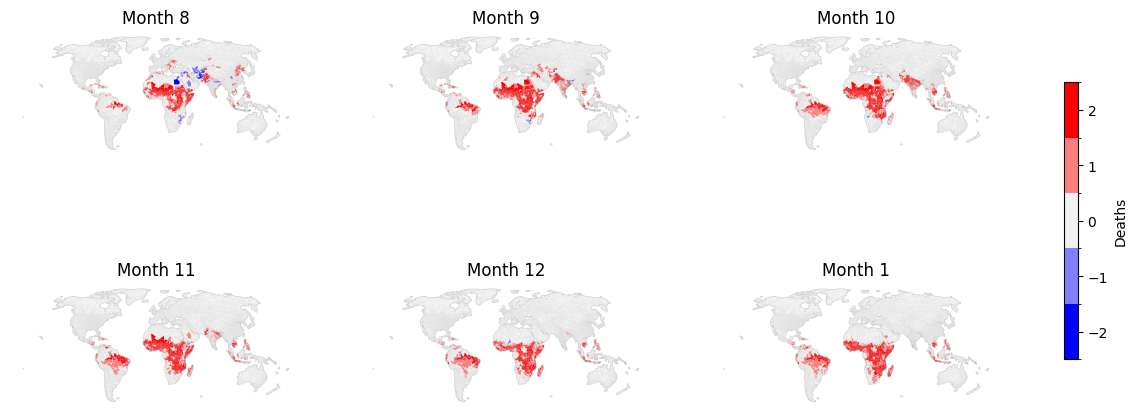

In [41]:
# Plot Impact on a Monthly Basis
fig = analysis_utils.plot_monthly(
    _polygons_impact,
    col='age0to4_impact',
    cm = 'bwr',
    sup_title="",
    cbar_label= impact.units,
    month_order= [8, 9, 10, 11, 12, 1]
)


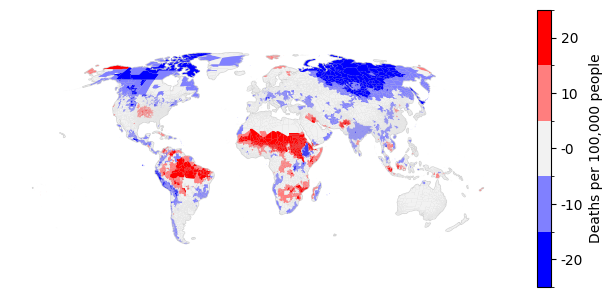

In [13]:
# Plot 6-month Cumulative Impact
fig = analysis_utils.plot_aggregate(
    _polygons_impact,
    col='age_weighted_impact',
    agg = 'sum',
    cm = 'bwr',
    sup_title="",
    cbar_label= impact.units,
)